## This is an example of iteration workflow --
![Workflow](images/iterative_workflow.png)

automatic workflow to post on the social media. 

To check the quality of the post, an evaluation method will be there. If the evaluation is not satisfied then it will be improved, an iterative method. Once the quality is satisfied then it will be posted. 

In [1]:
from langgraph.graph import StateGraph, START,END
from typing import TypedDict, Literal, Annotated
from dotenv import load_dotenv
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage
from pydantic import BaseModel, Field
import operator

load_dotenv()

c:\Users\banig\anaconda3\envs\torch\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


True

In [2]:
# may need to research which llm is suitable for the which task

generator_llm = ChatOpenAI(model= "gpt-4o")
evaluator_llm = ChatOpenAI(model= "gpt-4o-mini")
optimizer_llm = ChatOpenAI(model= "gpt-4o")


In [3]:
class TweetEvalSchema(BaseModel):
    evaluation: Literal['approval', "needs_improvement"] = Field(..., description="Final evaluation result.")
    feedback: str = Field(..., description="feedback for the tweet.")


In [4]:
structured_eval_llm = evaluator_llm.with_structured_output(TweetEvalSchema)

In [5]:
# state

class TweetState(TypedDict):
    topic : str
    tweet : str
    evaluation: Literal["approved", "need_improvement"]
    feedback: str
    iteration: int
    max_iteration: int


    # to store tweets at each iteration. 
    tweet_history: Annotated[list[str], operator.add]
    feedback_history: Annotated[list[str], operator.add]
    

In [6]:
def generate_tweet(state:TweetState):

    # prompt
    prompt = [
        SystemMessage(content=f" You are a funny and clever Twitter/X influencer"),
        HumanMessage(content=f"""
Write a short, original, and hilarious tweet on the topic : "{state['topic']}".
Rules:
- Do NOT use question-answer format.
- Max 280 characters. 
- Use observational humor, irony, sarcasm, or cultural references. 
- Think in meme logic, punchlines, or relatable takes. 
- Use simple, day to day english. 
""")]
    
    # send to the generator LLM

    out = generator_llm.invoke(prompt).content

    return {'tweet':out, "tweet_history":[out]}
    


In [7]:
def evaluate_tweet(state:TweetState):

    # prompt for evaluation method
    prompt = [
        SystemMessage(f"""You are a ruthless, no-laugh-given Twitter critic. You evaluate tweets based on humor, originality, virality, and tweet format. """),
        HumanMessage(f"""

Evaluate the following tweet 
                     Tweet: '{state["tweet"]}'
                     Use the criteria below to evaluate the tweet:
                     1. Originality- is this fresh, or have you seen it a hundred times before?
                     2. Humor - Did it genuinely make you smile, laugh, or chuckle?
                     3. Punchiness - Is it short, sharp, and scroll-stopping?
                     4. Virality Potential - Would people retweet or share it?
                     5. Format - is it a well-formed tweet( not a setup-punchlinejoke, not a Q&A joke, and under 280 character)
Auto-reject if:
- It;s written in question-answer format (e.g., 'why did...', or 'what happens when....')
- It exceeds 280 characters. 
- It reads like a traditional setup-punchline joke. 
- Don't end with generic, throwaway, or deflating line that weaken the humor. 

### Respond ONLY in structured format:
- evaluation: "approaved" or " needs_improvement"
- feedback : one paragraph explaining the strenghts and weakness.

""")
    ]

    out = structured_eval_llm.invoke(prompt)

    return {'evaluation': out.evaluation, 'feedback': out.feedback, 'feedback_history':[out.feedback]}


In [8]:
def optimize_tweet(state:TweetState):
    prompt = [

        SystemMessage(content="You punch up tweets for virality and humor based on given feedback"),
        HumanMessage(content=f"""

Improve the tweet based on this feedback:
                     "{state['feedback']}"
                     Topic: "{state["topic"]}"
                     Original tweet: {state['tweet']}

Re-write it as a short, viral-worthy tweet. Avoid Q&A style and under 280 characters.
""")
    ]

    out = optimizer_llm.invoke(prompt).content
    iteration = state['iteration']+1

    return {"tweet":out, 'iteration': iteration, "tweet_history":[out]}

In [ ]:
def route_eval(state:TweetState):

    if state['evaluation'] == 'approaved' or state['iteration'] >= state['max_iteration']:
        return "approaved"
    
    else:
        return "needs_improvement"

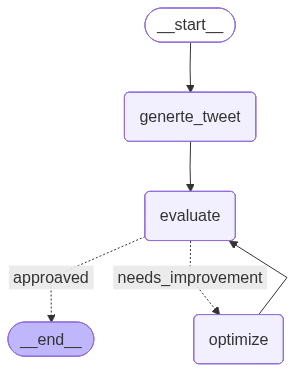

In [10]:
graph = StateGraph(TweetState)

graph.add_node("generte_tweet", generate_tweet)
graph.add_node("evaluate", evaluate_tweet)
graph.add_node("optimize", optimize_tweet)


graph.add_edge(START,"generte_tweet" )
graph.add_edge("generte_tweet", "evaluate")
graph.add_conditional_edges("evaluate",route_eval, {'approaved': END, "needs_improvement":"optimize"})
graph.add_edge("optimize", "evaluate")

workflow = graph.compile()

workflow

In [36]:
initital = {
    'topic': "Indian Railways",
    "iteration": 1,
    "max_iteration":5
}

workflow.invoke(initital)

c:\Users\banig\anaconda3\envs\torch\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TweetEvalSchema(evaluatio...a solid tweet overall."), input_type=TweetEvalSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\banig\anaconda3\envs\torch\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed', input_value=TweetEvalSchema(evaluatio...r needed for approval."), input_type=TweetEvalSchema])
  return self.__pydantic_serializer__.to_python(
c:\Users\banig\anaconda3\envs\torch\Lib\site-packages\pydantic\main.py:475: UserWarning: Pydantic serializer warnings:
  PydanticSerializationUnexpectedValue(Expected `none` - serialized value may not be as expected [field_name='parsed'

{'topic': 'Indian Railways',
 'tweet': '"Boarding an Indian train is like buying a lottery ticket; one minute you\'re a VIP with a window seat, the next you\'re part of an impromptu potluck featuring Auntie’s famous theplas. 🎟️🚂 #TrainAdventures"',
 'evaluation': 'approval',
 'feedback': "This tweet showcases originality by creatively comparing the experience of boarding an Indian train to a lottery ticket, which is a fresh take. The humor is present in the element of surprise and the relatable imagery of an impromptu potluck, making it likely to elicit a smile. It's punchy and effectively captures a chaotic but enjoyable moment in travel. The hashtag #TrainAdventures is fitting, enhancing its connectability for the audience. The format is perfect, adhering to the tweet structure without any pitfalls. Overall, it's likely to be shared due to its relatable content and engaging narrative.",
 'iteration': 5,
 'max_iteration': 5,
 'tweet_history': ["Indian Railways: where your seat is rese